# 🌍 Limpieza del Dataset Internacional de Partidos

**Objetivo:** Limpiar y normalizar el dataset masivo de resultados internacionales (`selecciones-partidos-completos.csv`).
Este dataset contiene más de 47.000 partidos desde 1872. Para nuestro modelo predictivo del Mundial 2026, nos enfocaremos en los partidos desde el año 2010 en adelante, ya que reflejan de forma más precisa el nivel futbolístico moderno de cada selección.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

RAW_DIR = '../datasets/raw'
CLEAN_DIR = '../datasets/processed'

df = pd.read_csv(os.path.join(RAW_DIR, 'selecciones-partidos-completos.csv'))
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


## 1. Exploración Inicial
Antes de limpiar, siempre debemos explorar el dataset para entender qué datos tenemos, sus tipos y cuántos valores nulos (NaN) existen.

In [ ]:
def reporte_calidad(data):
    print(f'Shape: {data.shape}')
    #Hay una enorme cantidad de registros pero no nos interesan los antiguos
    print(f'Duplicados: {data.duplicated().sum()}')
    nulos = data.isnull().sum()
    pct = (nulos / len(data)) * 100
    print('\nNulos por columna:')
    print(pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct.round(2)}))
    print('\nTipos de datos:')
    print(data.dtypes)

reporte_calidad(df)

: 

## 2. Visualización de Nulos y Distribución Temporal
Entender visualmente cómo se distribuyen los datos en el tiempo.

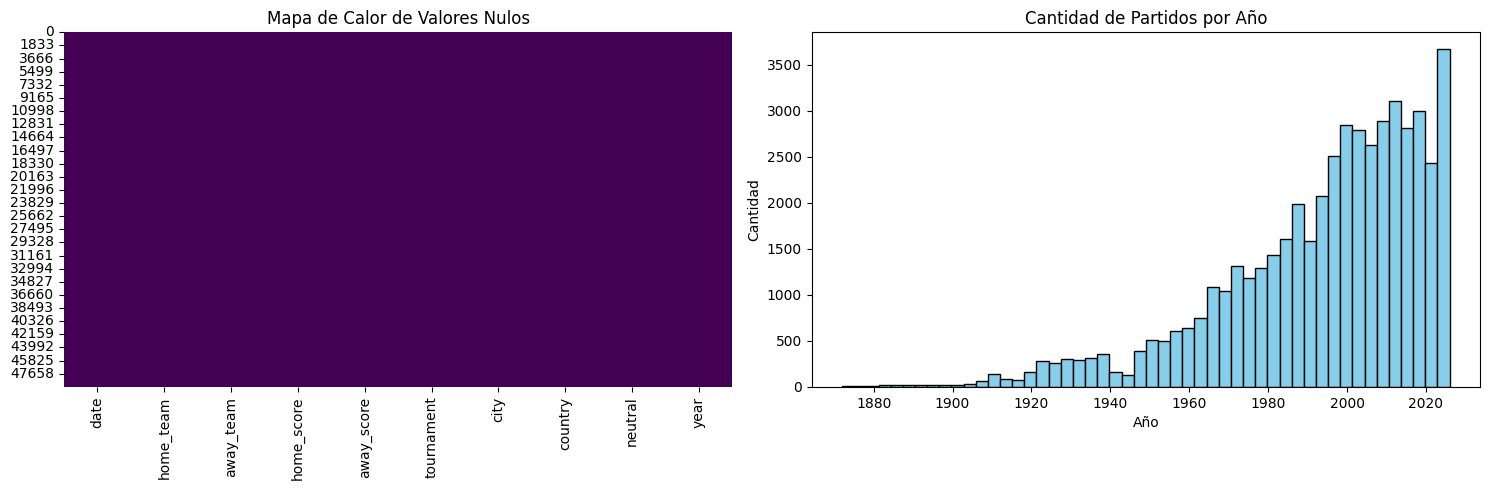

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap de nulos
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Mapa de Calor de Valores Nulos')

# Distribución de partidos por año
df['year'] = pd.to_datetime(df['date'], errors='coerce').dt.year
axes[1].hist(df['year'].dropna(), bins=50, color='skyblue', edgecolor='black')
axes[1].set_title('Cantidad de Partidos por Año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

## 3. Filtrado por Año — Solo desde 2010
El fútbol de 1950 no nos sirve para predecir el 2026. Al filtrar desde 2010 nos quedamos con los datos más representativos del nivel actual.

In [14]:
print(f'Partidos antes de 2010: {(df["year"] < 2010).sum()}')
print(f'Partidos desde 2010: {(df["year"] >= 2010).sum()}')

# Filtrar datos relevantes
df_filtrado = df[df['year'] >= 2010].copy()
print(f'Shape después del filtro: {df_filtrado.shape}')

Partidos antes de 2010: 33588
Partidos desde 2010: 15889
Shape después del filtro: (15889, 10)


## 4. Eliminación de Valores Nulos (NaN)
Los nulos en los resultados indican partidos suspendidos o que todavía no se jugaron.

In [15]:
print(f'Filas con score nulo ANTES: {df_filtrado[["home_score","away_score"]].isnull().any(axis=1).sum()}')
df_filtrado.dropna(subset=['home_score', 'away_score'], inplace=True)
df_filtrado['home_score'] = df_filtrado['home_score'].astype(int)
df_filtrado['away_score'] = df_filtrado['away_score'].astype(int)
print(f'Filas con score nulo DESPUÉS: {df_filtrado[["home_score","away_score"]].isnull().any(axis=1).sum()}')
print(f'Shape final: {df_filtrado.shape}')

Filas con score nulo ANTES: 28
Filas con score nulo DESPUÉS: 0
Shape final: (15861, 10)


## 5. Normalización de Nombres de Equipos
Para cruzar con los datos del Mundial, 'United States' debe coincidir con 'USA', etc.

In [ ]:
normalizacion = {
    'United States': 'USA',
    'IR Iran': 'Iran',
    'Korea Republic': 'South Korea',
    'Korea DPR': 'North Korea',
    'Côte d\'Ivoire': 'Ivory Coast',
    'DR Congo': 'DR Congo',
    'Bosnia and Herzegovina': 'Bosnia-Herzegovina',
    'Türkiye': 'Turkey',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'São Tomé and Príncipe': 'Sao Tome and Principe',
    'West Germany': 'Germany',
    'Soviet Union': 'Russia',
    'Zaire': 'DR Congo',
    'Dutch East Indies': 'Indonesia',
    'Czechoslovakia': 'Czech Republic'
}
df_filtrado['home_team'] = df_filtrado['home_team'].replace(normalizacion)
df_filtrado['away_team'] = df_filtrado['away_team'].replace(normalizacion)
print('Normalización aplicada.')

## 6. Clasificación por Tipo de Torneo
Diferenciamos la importancia de los torneos: Mundial > Eliminatoria > Continental > Amistoso.

Distribución por tipo de torneo:
tipo_torneo
eliminatoria        6128
amistoso            5073
otro                2226
copa_continental    2105
mundial              329
Name: count, dtype: int64


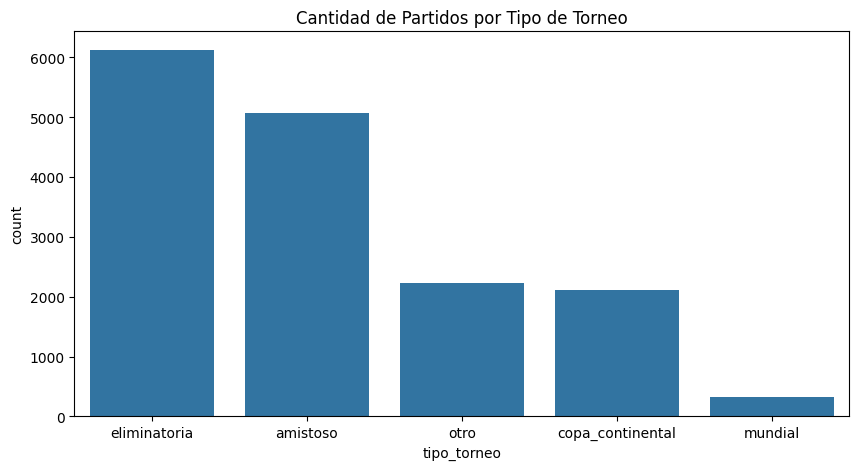

In [16]:
def clasificar_torneo(nombre):
    nombre = str(nombre).lower()
    if 'world cup' in nombre and 'qualif' not in nombre:
        return 'mundial'
    elif 'qualif' in nombre or 'eliminatoria' in nombre:
        return 'eliminatoria'
    elif any(x in nombre for x in ['copa america', 'euro', 'african cup', 'gold cup', 'asian cup', 'nations league', 'concacaf', 'conmebol']):
        return 'copa_continental'
    elif 'friendly' in nombre:
        return 'amistoso'
    else:
        return 'otro'

df_filtrado['tipo_torneo'] = df_filtrado['tournament'].apply(clasificar_torneo)
print('Distribución por tipo de torneo:')
print(df_filtrado['tipo_torneo'].value_counts())

# Gráfico
plt.figure(figsize=(10, 5))
sns.countplot(data=df_filtrado, x='tipo_torneo', order=df_filtrado['tipo_torneo'].value_counts().index)
plt.title('Cantidad de Partidos por Tipo de Torneo')
plt.show()

## 7. Eliminación de Columnas Irrelevantes y Duplicados

In [ ]:
# City no aporta al modelo porque no nos interesa
df_filtrado.drop(columns=['city'], inplace=True)

# Verificar y eliminar duplicados
duplicados = df_filtrado.duplicated().sum()
print(f'Duplicados encontrados: {duplicados}')
if duplicados > 0:
    df_filtrado.drop_duplicates(inplace=True)
df_filtrado.reset_index(drop=True, inplace=True)
print(f'Shape final limpio: {df_filtrado.shape}')

## 8. Exportación del Dataset Limpio

In [ ]:
os.makedirs(CLEAN_DIR, exist_ok=True)
df_filtrado.to_csv(os.path.join(CLEAN_DIR, 'partidos_internacionales_limpios.csv'), index=False)
print(f'Dataset exportado: {len(df_filtrado)} partidos')
print(f'Columnas finales: {list(df_filtrado.columns)}')
df_filtrado.head()